In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load the processed dataset + set the figures folder**

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/drive/MyDrive/bigdata-gbl-quiz"
PROCESSED_FILE = os.path.join(PROJECT_ROOT, "data", "processed", "quiz_features.csv")
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")

os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(PROCESSED_FILE)
print("Shape:", df.shape)
df.head()

Shape: (19991, 15)


,learner_id,question_id,topic,difficulty,time_spent_seconds,attempts_count,hints_used,correct,time_per_attempt,attempt_index,recent_success_5,recent_hints_5,recent_time_5,questions_completed,avg_difficulty_so_far
0,L0001,Q0103,Geography,2,73,3,2,0,24.333333,1,0.500000,0.0,56.000000,1,2.000000
1,L0001,Q0561,History,2,74,3,1,0,24.666667,2,0.000000,2.0,73.000000,2,2.000000
2,L0001,Q0189,ArtsCulture,1,37,2,0,1,18.500000,3,0.000000,1.5,73.500000,3,2.000000
3,L0001,Q0443,ArtsCulture,1,60,2,1,0,30.000000,4,0.333333,1.0,61.333333,4,1.666667
4,L0001,Q0392,Technology,1,33,2,0,1,16.500000,5,0.250000,1.0,61.000000,5,1.500000


**Quick summary numbers**

In [3]:
print("Rows:", len(df))
print("Learners:", df["learner_id"].nunique())
print("Questions:", df["question_id"].nunique())
print("Overall accuracy:", round(df["correct"].mean(), 3))

print("\nAccuracy by difficulty:")
print(df.groupby("difficulty")["correct"].mean().round(3))

print("\nMean time by difficulty:")
print(df.groupby("difficulty")["time_spent_seconds"].mean().round(1))

Rows: 19991
Learners: 300
Questions: 600
Overall accuracy: 0.326

Accuracy by difficulty:
difficulty
1    0.429
2    0.278
3    0.162
Name: correct, dtype: float64

Mean time by difficulty:
difficulty
1    38.5
2    68.1
3    97.2
Name: time_spent_seconds, dtype: float64


**Now we make 5 core figures (save each one)**

Figure 1: Accuracy by difficulty

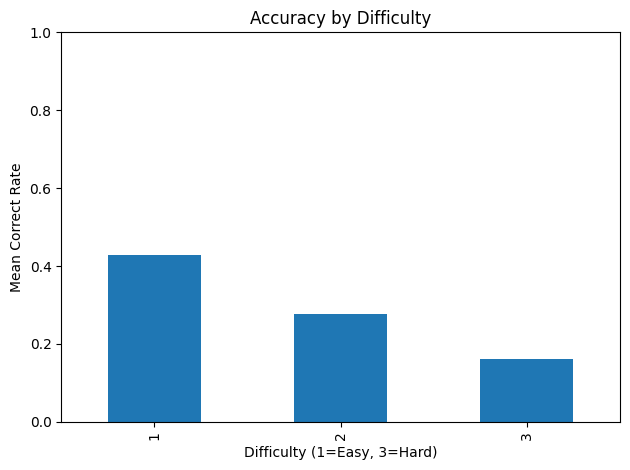

Saved: /content/drive/MyDrive/bigdata-gbl-quiz/figures/fig1_accuracy_by_difficulty.png


In [4]:
acc_by_diff = df.groupby("difficulty")["correct"].mean().sort_index()

plt.figure()
acc_by_diff.plot(kind="bar")
plt.title("Accuracy by Difficulty")
plt.xlabel("Difficulty (1=Easy, 3=Hard)")
plt.ylabel("Mean Correct Rate")
plt.ylim(0, 1)
plt.tight_layout()

out = os.path.join(FIG_DIR, "fig1_accuracy_by_difficulty.png")
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

**Figure 2: Time spent distribution (histogram)**

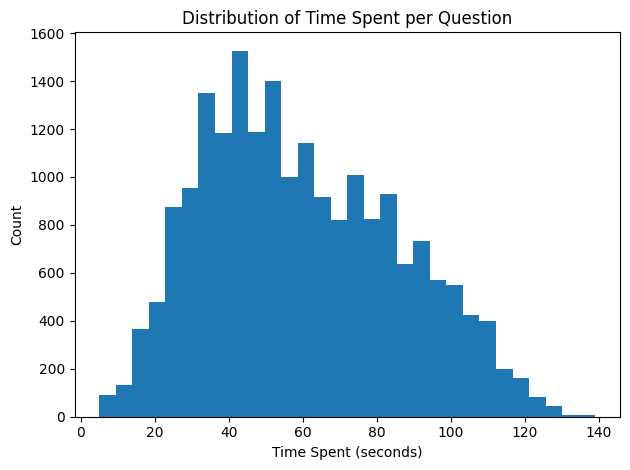

Saved: /content/drive/MyDrive/bigdata-gbl-quiz/figures/fig2_time_distribution.png


In [5]:
plt.figure()
plt.hist(df["time_spent_seconds"], bins=30)
plt.title("Distribution of Time Spent per Question")
plt.xlabel("Time Spent (seconds)")
plt.ylabel("Count")
plt.tight_layout()

out = os.path.join(FIG_DIR, "fig2_time_distribution.png")
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

**Figure 3: Time by difficulty (boxplot)**

/tmp/ipykernel_237/3827341340.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(d) for d in sorted(df["difficulty"].unique())])


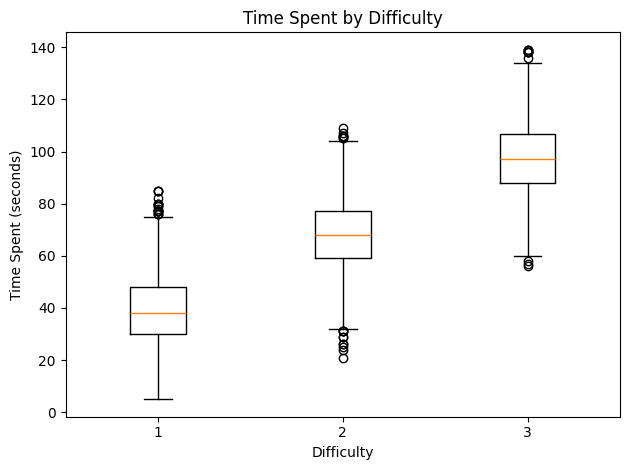

Saved: /content/drive/MyDrive/bigdata-gbl-quiz/figures/fig3_time_by_difficulty_boxplot.png


In [6]:
data = [df.loc[df["difficulty"] == d, "time_spent_seconds"] for d in sorted(df["difficulty"].unique())]

plt.figure()
plt.boxplot(data, labels=[str(d) for d in sorted(df["difficulty"].unique())])
plt.title("Time Spent by Difficulty")
plt.xlabel("Difficulty")
plt.ylabel("Time Spent (seconds)")
plt.tight_layout()

out = os.path.join(FIG_DIR, "fig3_time_by_difficulty_boxplot.png")
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

**Figure 4: Accuracy by hints used**

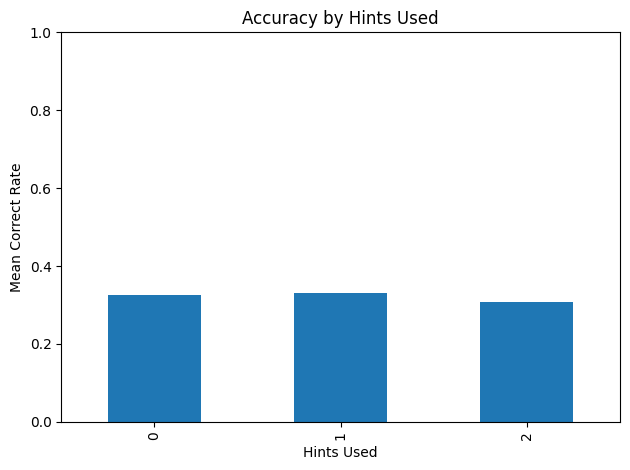

Saved: /content/drive/MyDrive/bigdata-gbl-quiz/figures/fig4_accuracy_by_hints.png


In [7]:
hint_acc = df.groupby("hints_used")["correct"].mean().sort_index()

plt.figure()
hint_acc.plot(kind="bar")
plt.title("Accuracy by Hints Used")
plt.xlabel("Hints Used")
plt.ylabel("Mean Correct Rate")
plt.ylim(0, 1)
plt.tight_layout()

out = os.path.join(FIG_DIR, "fig4_accuracy_by_hints.png")
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

**Figure 5: Accuracy by attempts**

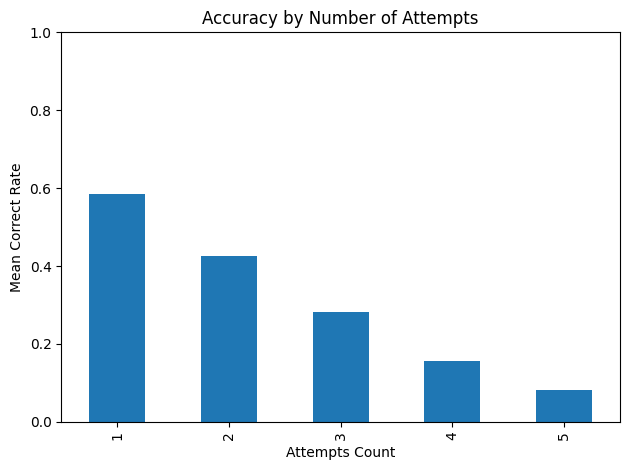

Saved: /content/drive/MyDrive/bigdata-gbl-quiz/figures/fig5_accuracy_by_attempts.png


In [8]:
att_acc = df.groupby("attempts_count")["correct"].mean().sort_index()

plt.figure()
att_acc.plot(kind="bar")
plt.title("Accuracy by Number of Attempts")
plt.xlabel("Attempts Count")
plt.ylabel("Mean Correct Rate")
plt.ylim(0, 1)
plt.tight_layout()

out = os.path.join(FIG_DIR, "fig5_accuracy_by_attempts.png")
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

**One summary table**

In [9]:
summary = df.groupby("difficulty").agg(
    mean_correct=("correct", "mean"),
    mean_time=("time_spent_seconds", "mean"),
    mean_hints=("hints_used", "mean"),
    mean_attempts=("attempts_count", "mean"),
    rows=("correct", "size")
).round(3)

summary

,mean_correct,mean_time,mean_hints,mean_attempts,rows
difficulty,,,,,
1,0.429,38.506,0.374,2.028,9548
2,0.278,68.052,0.560,3.039,6405
3,0.162,97.167,0.756,4.016,4038


In [10]:
import os
PROJECT_ROOT = "/content/drive/MyDrive/bigdata-gbl-quiz"
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
print("FIG_DIR =", FIG_DIR)
print("Exists?", os.path.exists(FIG_DIR))

FIG_DIR = /content/drive/MyDrive/bigdata-gbl-quiz/figures
Exists? True
